# LINMA2471 - Optimization Models and Methods II
## Project: Markowitz Portfolio Optimization

---

<p></p>

### Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Force reload of modules (important après modification des fichiers .py)
import importlib
import models
import methods
import data
import utils
importlib.reload(models)
importlib.reload(methods)
importlib.reload(data)
importlib.reload(utils)

from models import *
from methods import *
from data import *
from utils import *

### Load data

In [2]:
processor = DataProcessor()
data = processor.get_optimization_data()

### Load model

In [3]:
# Create Smooth Model instance
model = SmoothMarkowitzModel({
    "mu": data['mu'],
    "sigma": data['sigma'],
    "lam": 0.5
})


### Compute Optimal Reference Value (f_ref) with CVXPY

In [4]:
import cvxpy as cp

def solve_markowitz_cvxpy(mu, sigma, lam):
    
    n = len(mu)
    w = cp.Variable(n)
    
    objective = cp.Minimize(0.5 * cp.quad_form(w, sigma) - lam * mu @ w)
    
    constraints = [
        cp.sum(w) == 1,
        w >= 0
    ]
    
    problem = cp.Problem(objective, constraints)
    problem.solve(solver=cp.ECOS)  
    
    return {
        'w_opt': w.value,
        'f_opt': problem.value,
        'status': problem.status
    }

# Solve for optimal reference value
cvxpy_result = solve_markowitz_cvxpy(data['mu'], data['sigma'], model.lam)


# Store the reference value for later use
f_ref = cvxpy_result['f_opt']
w_opt = cvxpy_result['w_opt']

# Verify with our model
print(f"\nVerification with model.f(w_opt): {model.f(w_opt):.10f}")

(CVXPY) Dec 14 12:48:51 PM: Encountered unexpected exception importing solver GLOP:
RuntimeError('Unrecognized new version of ortools (9.11.4210). Expected < 9.8.0. Please open a feature request on cvxpy to enable support for this version.')
(CVXPY) Dec 14 12:48:51 PM: Encountered unexpected exception importing solver PDLP:
RuntimeError('Unrecognized new version of ortools (9.11.4210). Expected < 9.8.0. Please open a feature request on cvxpy to enable support for this version.')

Verification with model.f(w_opt): -0.0010487264


### Projected GD

In [5]:

# Compute Lipschitz constant for step size
L = model.lipschitz_constant()

# Create optimization method instance
method = ProjectedGradientMethod({
    'step_size': ExactLineSearchQuadratic(),
    'max_iter': 1000,
    'tol': 1e-8,
}, IteratePerformanceIndicator())

# Initial portfolio (equal weights)
w0 = get_initial_portfolio(data['mu'].shape[0])

# Optimize portfolio on training data
result_ProjectedGradientMethod = method.optimize(model, w0)

print("Keys disponibles:", result_ProjectedGradientMethod.keys())
print(f"Converged: {result_ProjectedGradientMethod['converged']}")
print(f"Iterations: {result_ProjectedGradientMethod['iterations']}")
#Plot valeur objectif en fonction des iterations





Keys disponibles: dict_keys(['sol', 'value', 'iterations', 'converged', 'metric', 'time', 'obj_value', 'step_sizes'])
Converged: True
Iterations: 493


#### Analyse convergence Projected gradient descent

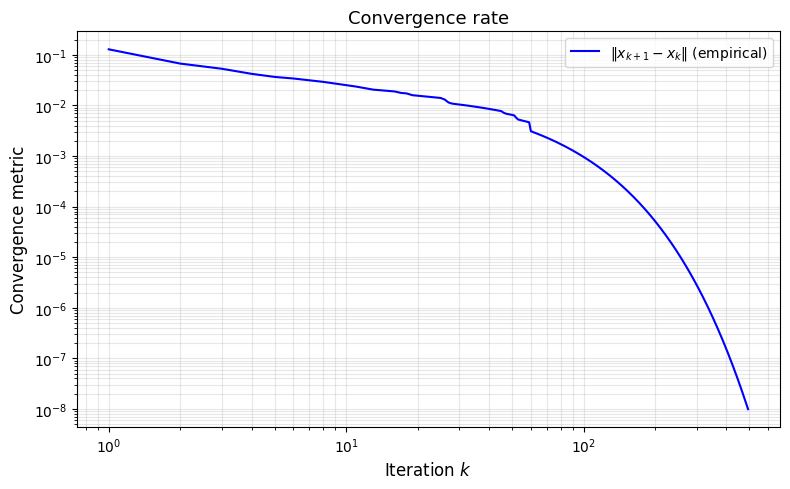

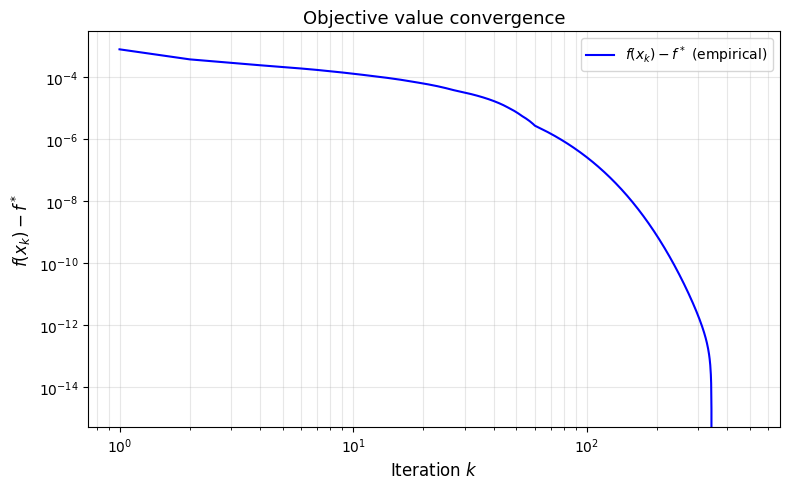

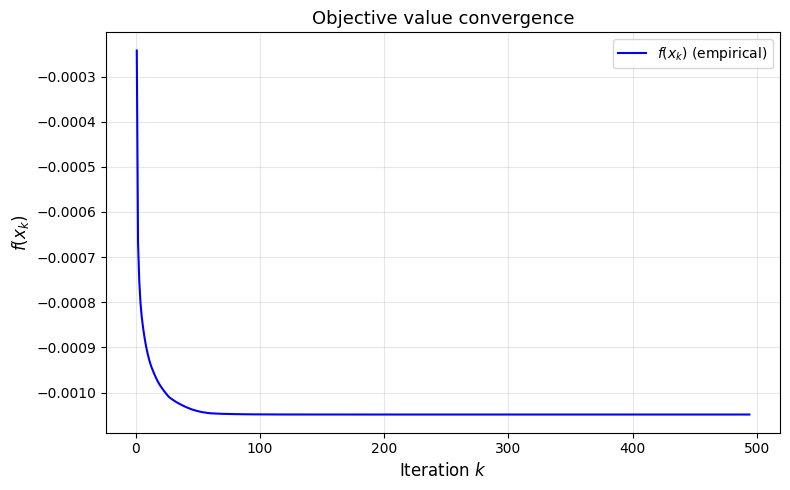

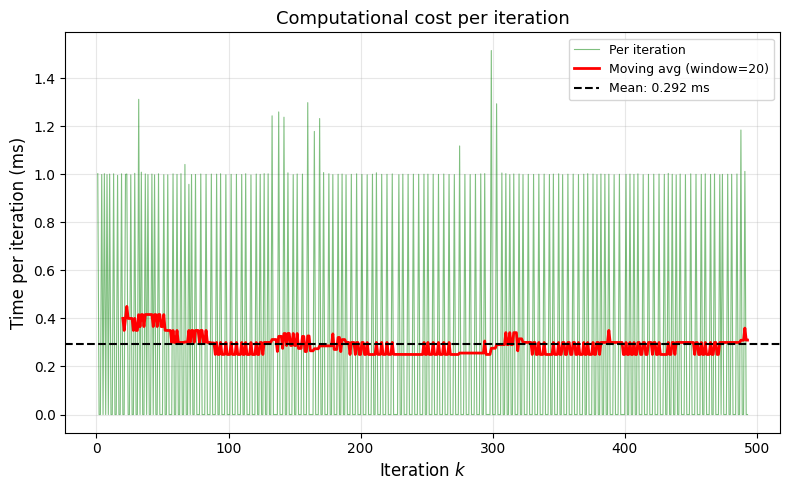

Total time: 0.1439 seconds
Total iterations: 493
Final objective value: -0.001049
Average time per iteration: 0.2919 ms
Std time per iteration: 0.4630 ms


In [6]:
# Plot convergence in iteration 


plot_convergence(result_ProjectedGradientMethod, theoretical_rate_exp=-0.5, rate_label=r'$O(k^{-1/2})$' , method_name="Classical_Projected_Gradient" , save_dir=None , metric_used='iterate' , f_ref=f_ref)

  tol=1.00e-02: 29 iterations
  tol=2.15e-03: 117 iterations
  tol=4.64e-04: 201 iterations
  tol=1.00e-04: 305 iterations
  tol=2.15e-05: 409 iterations
  tol=4.64e-06: 514 iterations
  tol=1.00e-06: 618 iterations
  tol=2.15e-07: 722 iterations
  tol=4.64e-08: 826 iterations
  tol=1.00e-08: 931 iterations


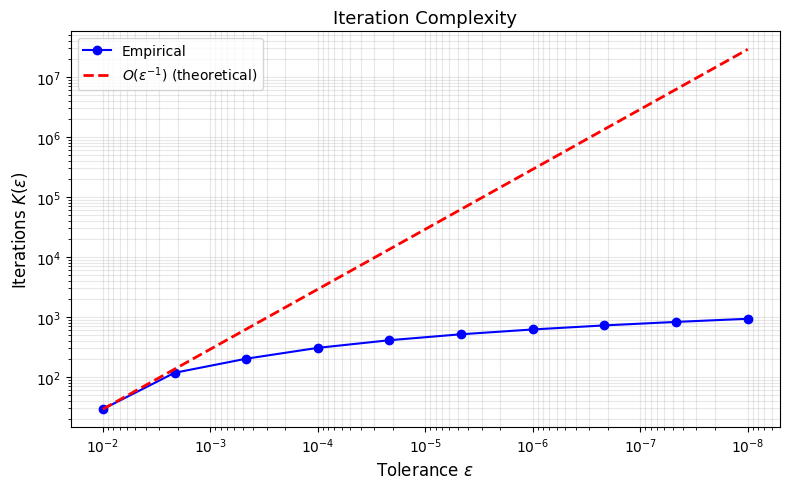

In [7]:
tolerances = np.logspace(-2, -8, 10)  # de 1e-2 à 1e-6

# Mesurer la complexité
result_complexity = measure_iteration_complexity(
    method_class=ProjectedGradientMethod,
    method_params={'step_size': 1.0 / L},
    model=model,
    w0=w0,
    tolerances=tolerances,
    theoretical_exp=1,
    rate_label=r'$O(\epsilon^{-1})$',
    method_name='Classical_Projected_Gradient',
    save_dir='../figures'
)

#### Analyse with different stepsize

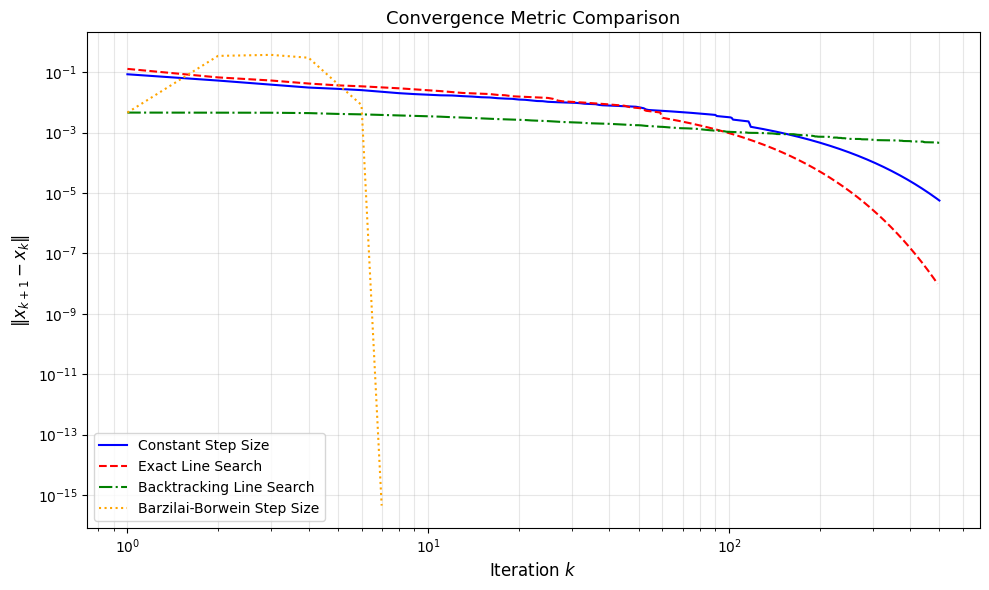

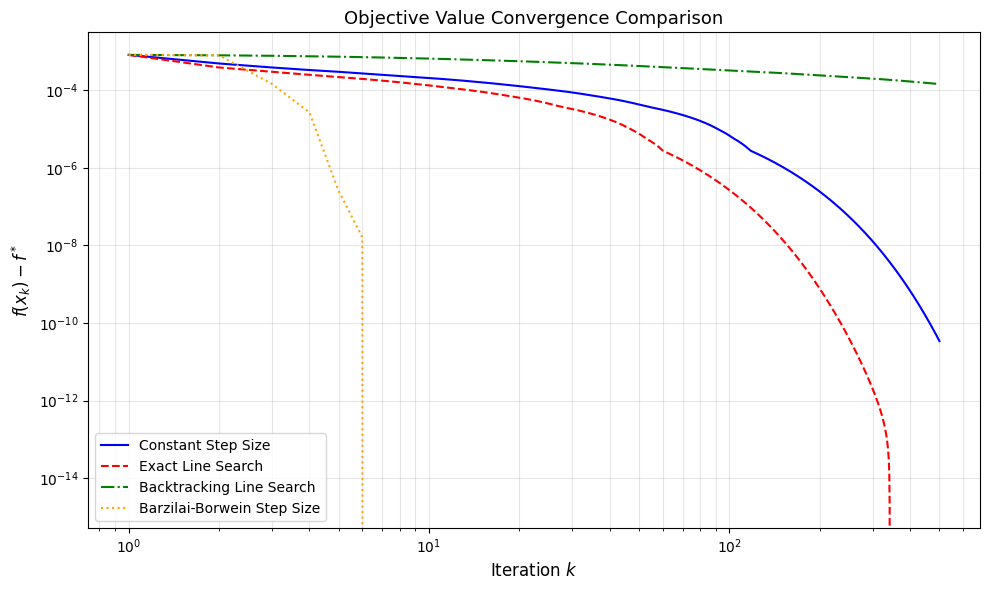

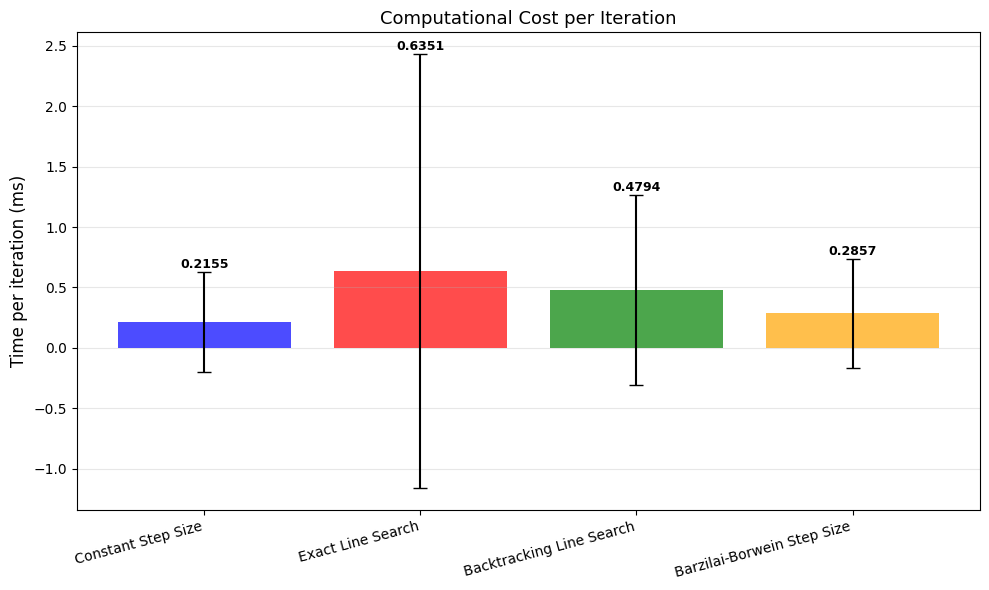


TIME PER ITERATION STATISTICS (ms)
Method                               Mean        Std     Median        Min        Max
-----------------------------------------------------------------------------------------------
Constant Step Size                 0.2155     0.4137     0.0000     0.0000     1.5035
Exact Line Search                  0.6351     1.7967     0.0000     0.0000    31.5259
Backtracking Line Search           0.4794     0.7884     0.0000     0.0000    13.9999
Barzilai-Borwein Step Size         0.2857     0.4518     0.0000     0.0000     1.0009

Method                          Total Time (s)   Iterations
------------------------------------------------------------
Constant Step Size                      0.1078          500
Exact Line Search                       0.3131          493
Backtracking Line Search                0.2397          500
Barzilai-Borwein Step Size              0.0020            7


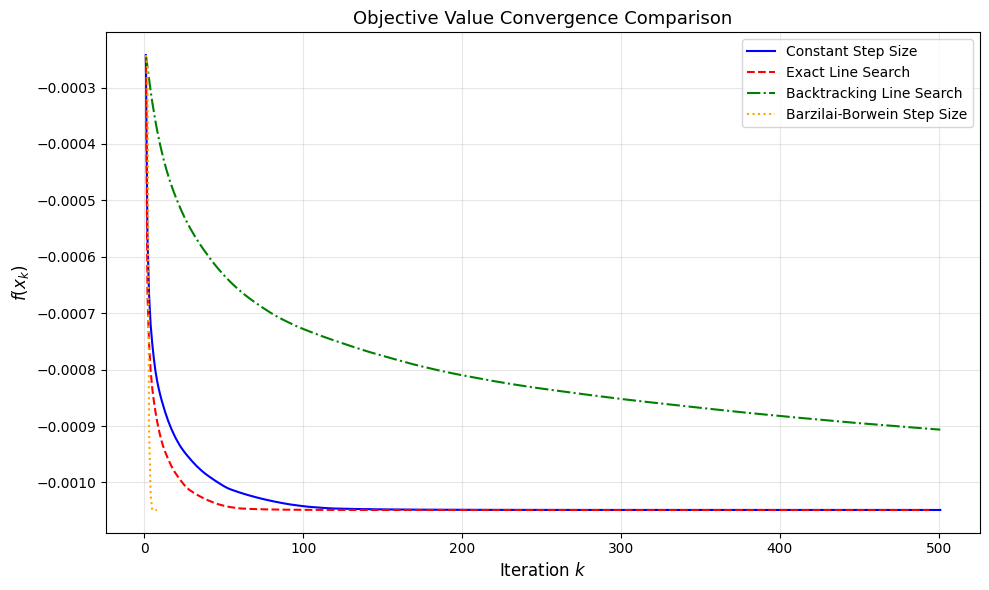

In [8]:
method1 = ProjectedGradientMethod({
    'step_size': ExactLineSearchQuadratic(),
    'max_iter': 500,
    'tol':1e-8,
}, IteratePerformanceIndicator())
method1_result = method1.optimize(model, w0)
method2 = ProjectedGradientMethod({
    'step_size': 1.0 / L,
    'max_iter': 500,
        'tol':1e-8,

}, IteratePerformanceIndicator())

method2_result = method2.optimize(model, w0)    

method3 =  ProjectedGradientMethod({
        'step_size': BacktrackingLineSearch(),
    'max_iter': 500,
        'tol':1e-8,

}, IteratePerformanceIndicator())
method3_result = method3.optimize(model, w0)

method4 = ProjectedGradientMethod({
    'step_size': BarzilaiBorweinStepSize('BB1'),
    'max_iter': 500,
        'tol':1e-8,

}, IteratePerformanceIndicator())
method4_result_PG = method4.optimize(model, w0)

methods = {"Constant Step Size": method2_result,
           "Exact Line Search": method1_result,
           "Backtracking Line Search": method3_result,
           "Barzilai-Borwein Step Size": method4_result_PG}
compare_methods(methods , method_name="Classical_Projected_Gradient_step_size_comparison" , save_dir="../figures" , metric_used='iterate', f_ref=f_ref)

### Projected gradient with momentum

In [30]:

L = model.lipschitz_constant()

# Create optimization method instance
method = ProjectedGradientDescentMomentum({
    'step_size': 1.0 / L,
    'max_iter': 1000,
    'tol': 1e-8,
    'momentum':0.9,
}, IteratePerformanceIndicator())

# Initial portfolio (equal weights)

# Optimize portfolio on training data
result_ProjectedGradientDescentMomentum = method.optimize(model, w0)

print("Keys disponibles:", result_ProjectedGradientDescentMomentum.keys())
print(f"Converged: {result_ProjectedGradientDescentMomentum['converged']}")
print(f"Iterations: {result_ProjectedGradientDescentMomentum['iterations']}")
#Plot valeur objectif en fonction des iterations





Keys disponibles: dict_keys(['sol', 'value', 'iterations', 'converged', 'metric', 'time', 'obj_value', 'step_sizes'])
Converged: True
Iterations: 811


#### Analyse convergence Projected gradient with momentum

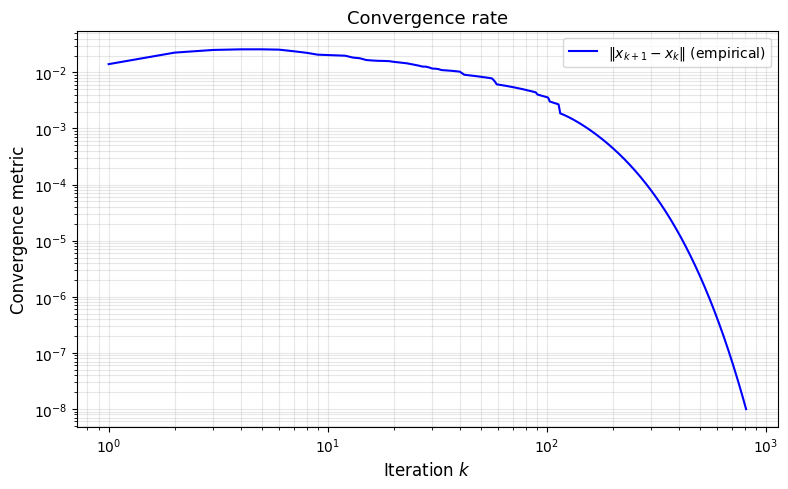

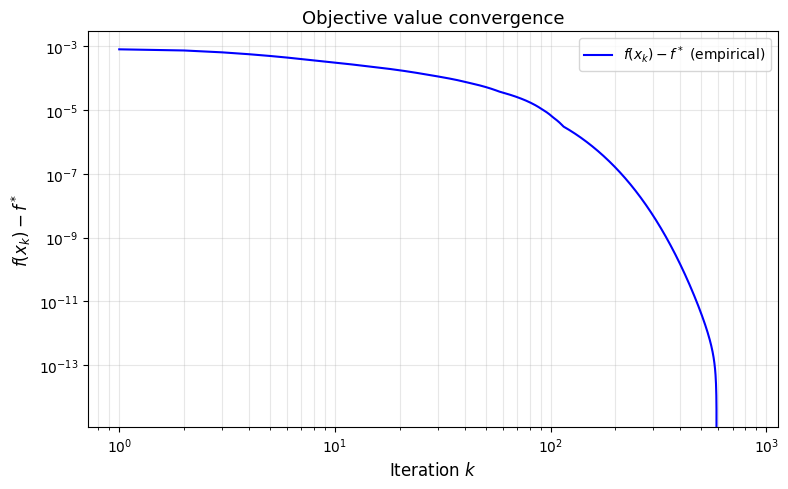

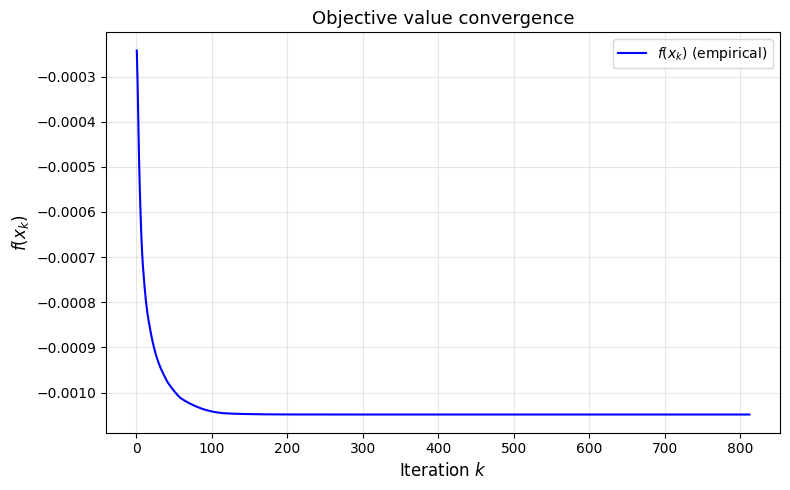

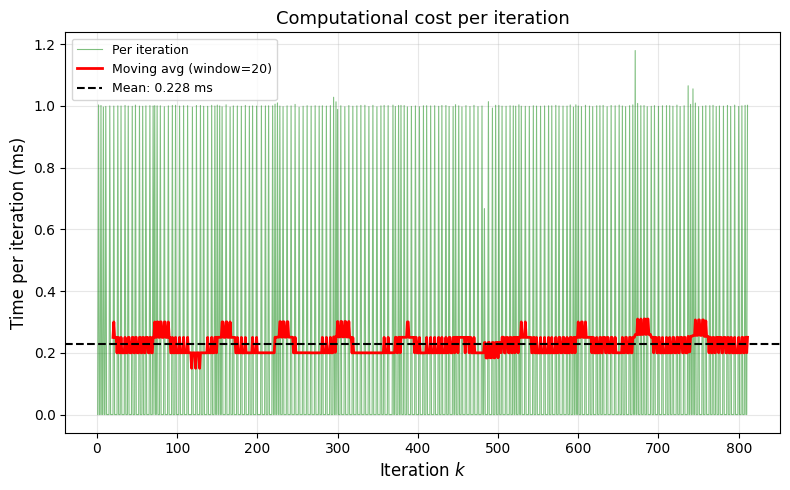

Total time: 0.1850 seconds
Total iterations: 811
Final objective value: -0.001049
Average time per iteration: 0.2282 ms
Std time per iteration: 0.4199 ms


In [10]:
plot_convergence(result_ProjectedGradientDescentMomentum , method_name="Projected_Gradient_momentum" , save_dir=None , f_ref=f_ref)

  tol=1.00e-02: 41 iterations
  tol=2.15e-03: 115 iterations
  tol=4.64e-04: 198 iterations
  tol=1.00e-04: 286 iterations
  tol=2.15e-05: 373 iterations
  tol=4.64e-06: 461 iterations
  tol=1.00e-06: 548 iterations
  tol=2.15e-07: 636 iterations
  tol=4.64e-08: 723 iterations
  tol=1.00e-08: 811 iterations


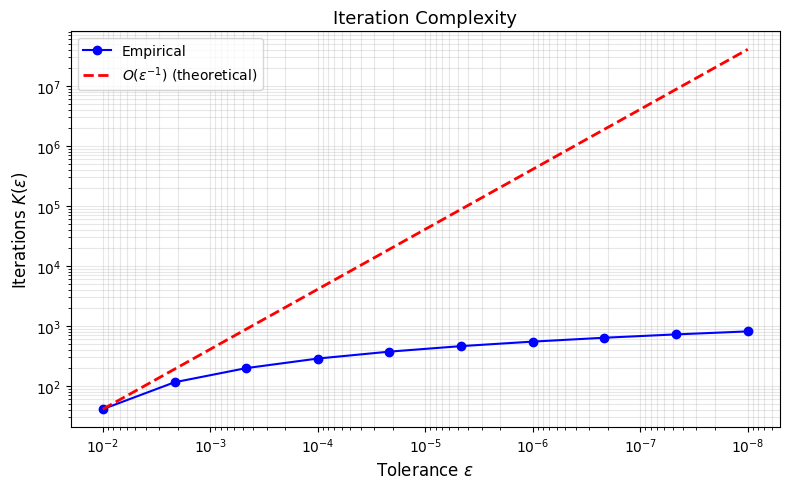

In [29]:
tolerances = np.logspace(-2, -8, 10)  # de 1e-2 à 1e-6

result_complexity = measure_iteration_complexity(
    method_class=ProjectedGradientDescentMomentum,
    method_params={
    'step_size': 1.0 / L,
    'max_iter': 1000,
    'tol': 1e-8,
    'momentum':0.9,
},
    model=model,
    w0=w0,
    tolerances=tolerances,
    theoretical_exp=1,
    rate_label=r'$O(\epsilon^{-1})$',
    method_name='ProjectedGD_momentum',
    save_dir='../figures'
)

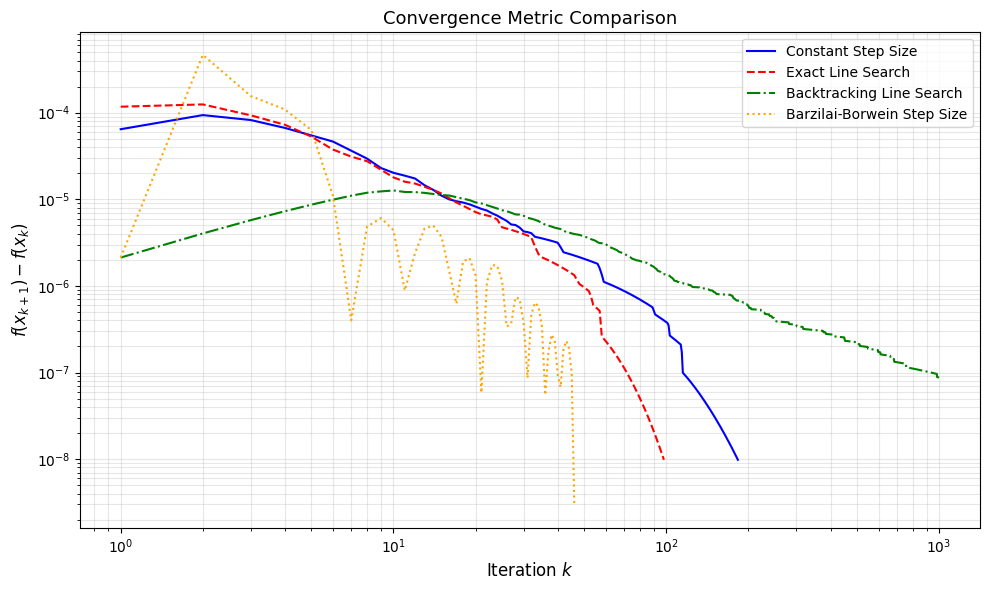

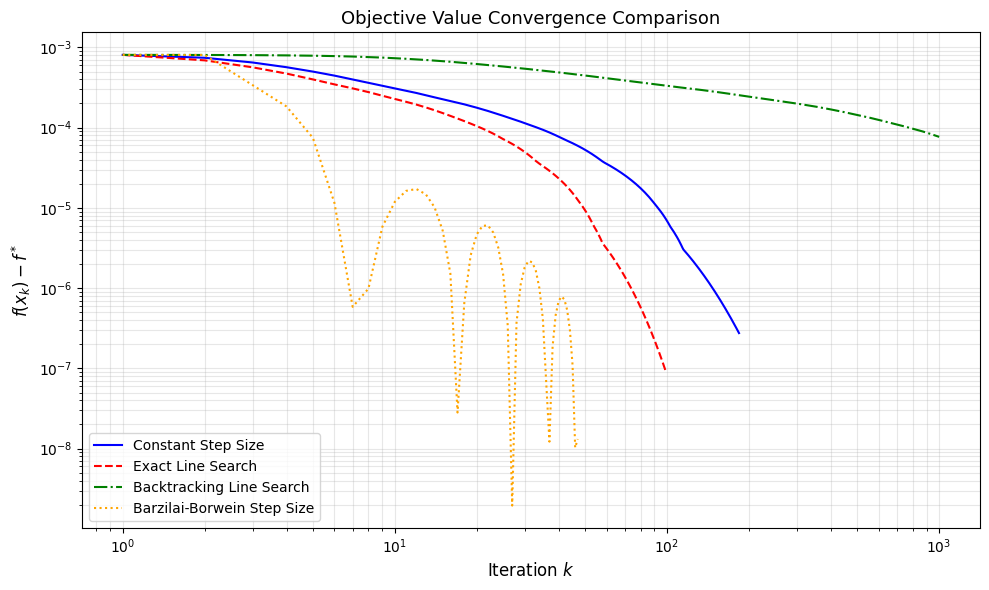

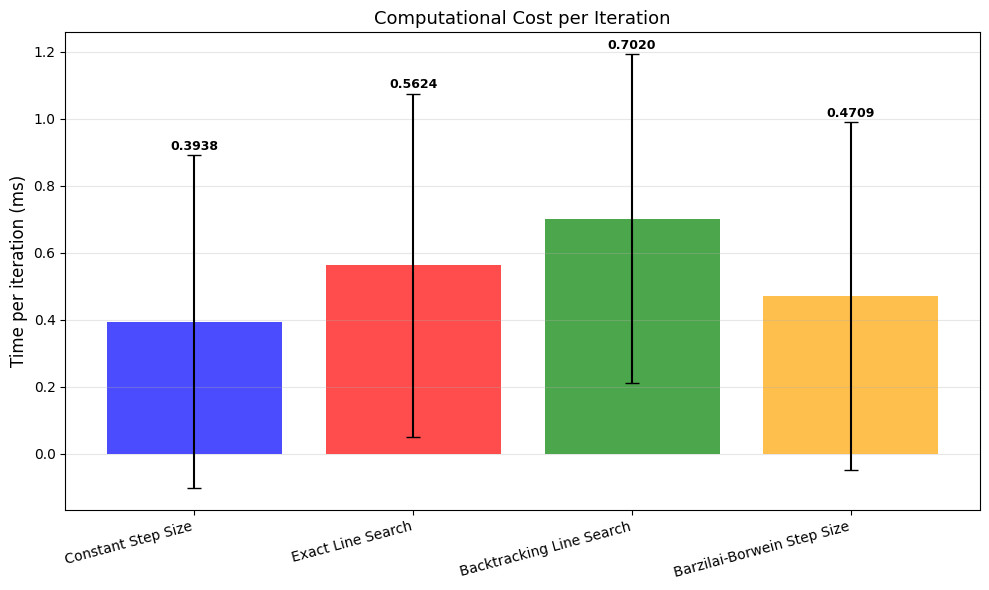


TIME PER ITERATION STATISTICS (ms)
Method                               Mean        Std     Median        Min        Max
-----------------------------------------------------------------------------------------------
Constant Step Size                 0.3938     0.4969     0.0000     0.0000     1.5051
Exact Line Search                  0.5624     0.5126     0.9971     0.0000     1.5104
Backtracking Line Search           0.7020     0.4913     0.9992     0.0000     2.0199
Barzilai-Borwein Step Size         0.4709     0.5185     0.0000     0.0000     1.4441

Method                          Total Time (s)   Iterations
------------------------------------------------------------
Constant Step Size                      0.0721          183
Exact Line Search                       0.0551           98
Backtracking Line Search                0.7020         1000
Barzilai-Borwein Step Size              0.0217           46


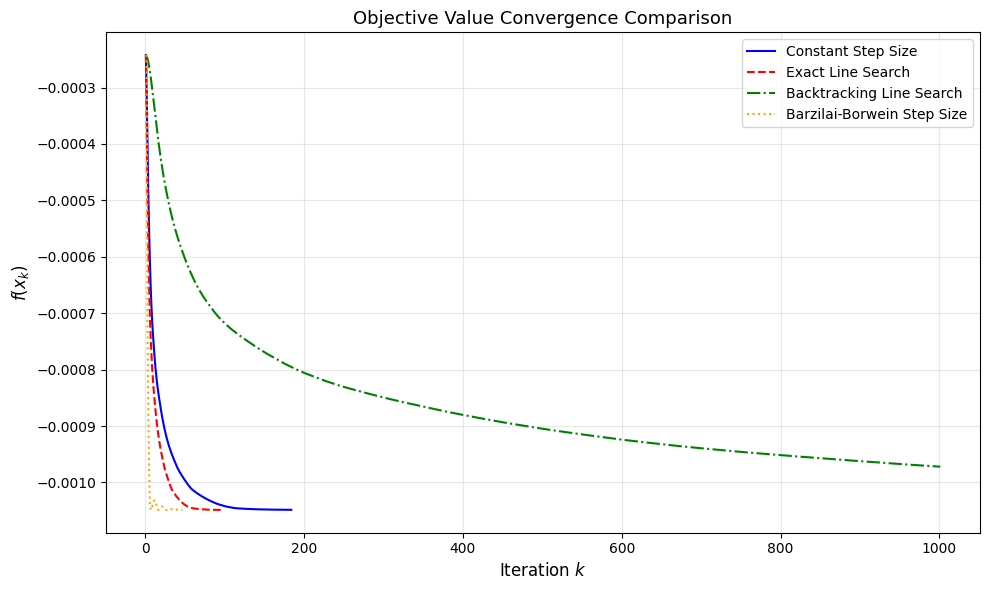

In [12]:
method1 = ProjectedGradientDescentMomentum({
    'step_size': ExactLineSearchQuadratic(),
    'max_iter': 1000,
        'tol': 1e-8,

}, ValuePerformanceIndicator())
method1_result = method1.optimize(model, w0)
method2 = ProjectedGradientDescentMomentum({
    'step_size': 1.0 / L,
    'max_iter': 1000,
        'tol': 1e-8,

}, ValuePerformanceIndicator())

method2_result = method2.optimize(model, w0)    

method3 =  ProjectedGradientDescentMomentum({
        'step_size': BacktrackingLineSearch(),
    'max_iter': 1000,
        'tol': 1e-8,

}, ValuePerformanceIndicator())
method3_result = method3.optimize(model, w0)

method4 = ProjectedGradientDescentMomentum({
    'step_size': BarzilaiBorweinStepSize('BB1'),
    'max_iter': 1000,
    'tol': 1e-8,
}, ValuePerformanceIndicator())
method4_result = method4.optimize(model, w0)

methods = {"Constant Step Size": method2_result,
           "Exact Line Search": method1_result,
           "Backtracking Line Search": method3_result,
           "Barzilai-Borwein Step Size": method4_result}
compare_methods(methods , method_name="Projected_Gradient_momentum_step_size" , save_dir="../figures" , metric_used='function',f_ref=f_ref)

#### Nesterov's Accelerated Gradient method


In [31]:
L = model.lipschitz_constant()
print(f_ref)
# Create optimization method instance
method = ProjectedGradientDescentMomentum_Nesterov({
    'step_size': 1.0 / L,
    'max_iter': 1000,
    'tol': 1e-8,
    'momentum':0.9,
}, IteratePerformanceIndicator())

# Initial portfolio (equal weights)
w0 = get_initial_portfolio(data['mu'].shape[0])

# Optimize portfolio on training data
result_ProjectedGradientDescentMomentum_Nesterov = method.optimize(model, w0)

print("Keys disponibles:", result_ProjectedGradientDescentMomentum_Nesterov.keys())
print(f"Converged: {result_ProjectedGradientDescentMomentum_Nesterov['converged']}")
print(f"Iterations: {result_ProjectedGradientDescentMomentum_Nesterov['iterations']}")
print("final objective value:", result_ProjectedGradientDescentMomentum_Nesterov['obj_value'][-1])
#Plot valeur objectif en fonction des iterations



-0.0010487263576789778
Keys disponibles: dict_keys(['sol', 'value', 'iterations', 'converged', 'metric', 'time', 'obj_value'])
Converged: True
Iterations: 799
final objective value: -0.0010487263578666402


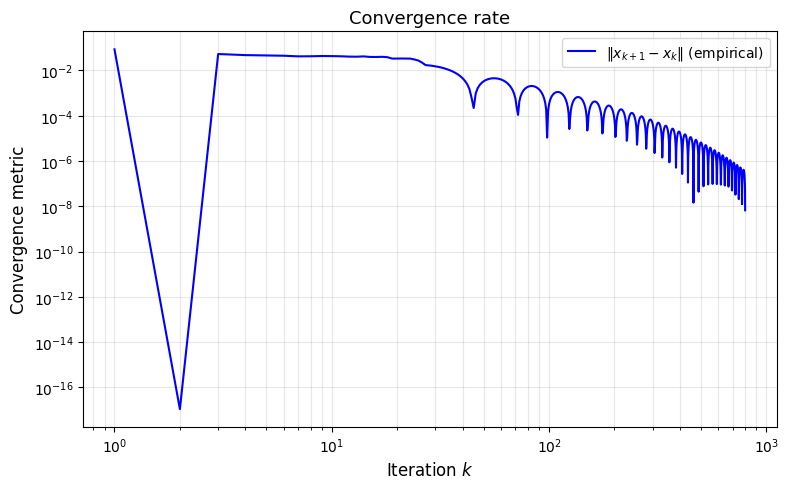

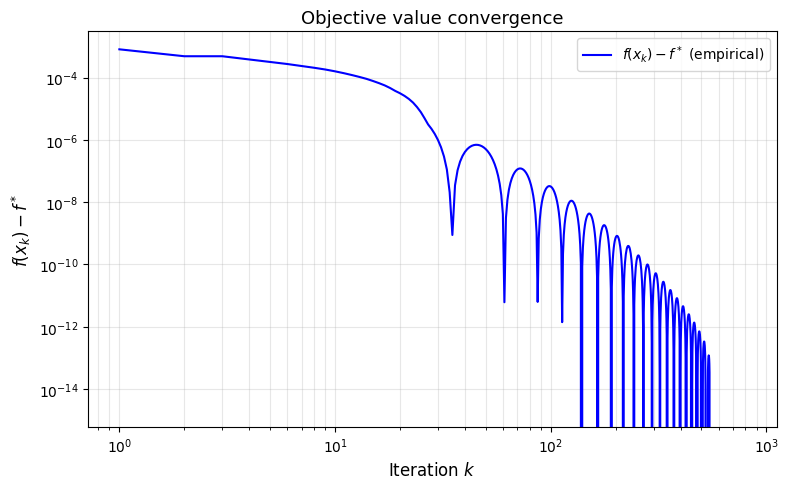

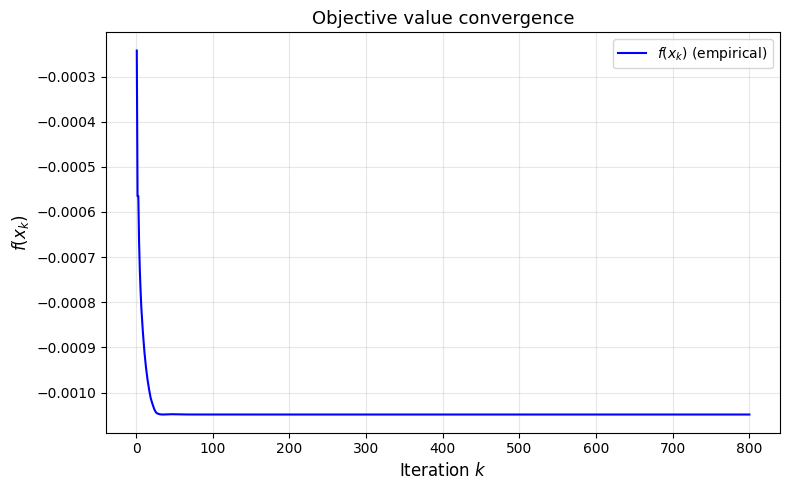

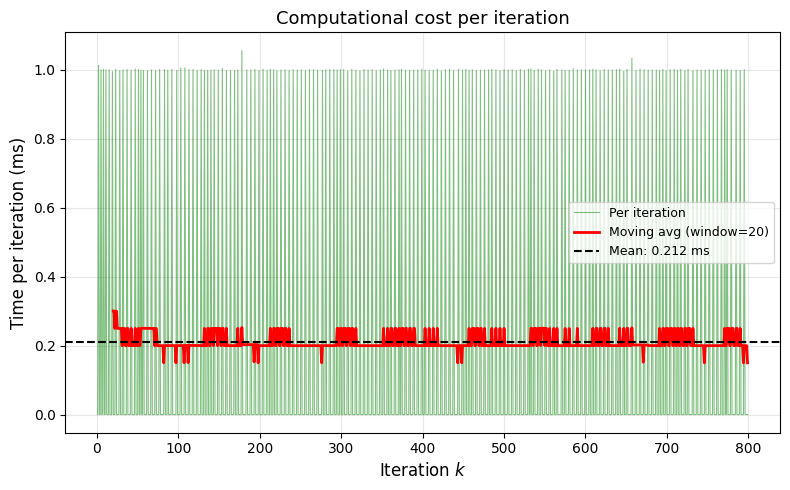

Total time: 0.1691 seconds
Total iterations: 799
Final objective value: -0.001049
Average time per iteration: 0.2117 ms
Std time per iteration: 0.4087 ms


In [14]:
plot_convergence(result_ProjectedGradientDescentMomentum_Nesterov , method_name="Projected_Gradient_Nesterov" , save_dir=None , metric_used='iterate' , f_ref=f_ref)

  tol=1.00e-02: 36 iterations
  tol=2.15e-03: 43 iterations
  tol=4.64e-04: 45 iterations
  tol=1.00e-04: 98 iterations
  tol=2.15e-05: 98 iterations
  tol=4.64e-06: 280 iterations
  tol=1.00e-06: 358 iterations
  tol=2.15e-07: 436 iterations
  tol=4.64e-08: 462 iterations
  tol=1.00e-08: 799 iterations


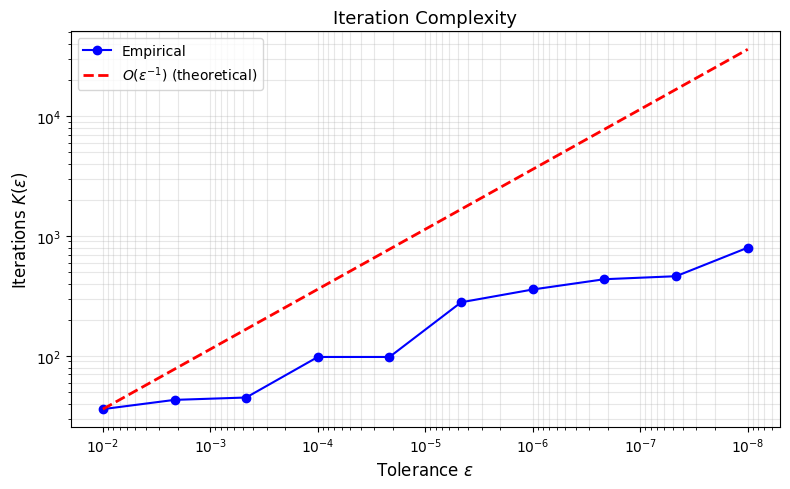

In [15]:
result_complexity = measure_iteration_complexity(
    method_class=ProjectedGradientDescentMomentum_Nesterov,
    method_params={'step_size': 1.0 / L},
    model=model,
    w0=w0,
    tolerances=tolerances,
    theoretical_exp=1/2,
    rate_label=r'$O(\epsilon^{-1})$',
    method_name='Projected_Gradient_Descent_Momentum_Nesterov',
    save_dir='../figures'
)

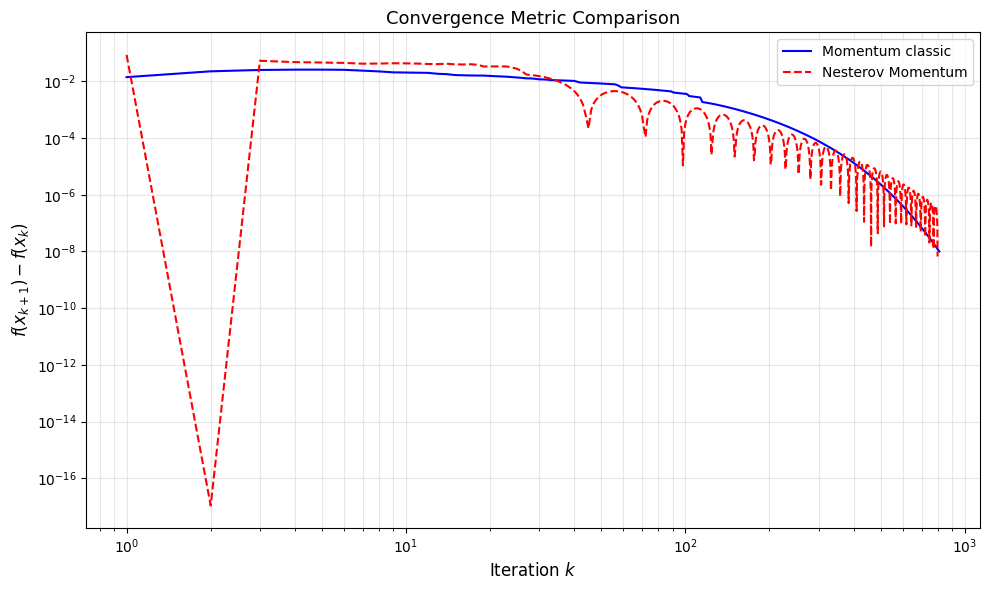

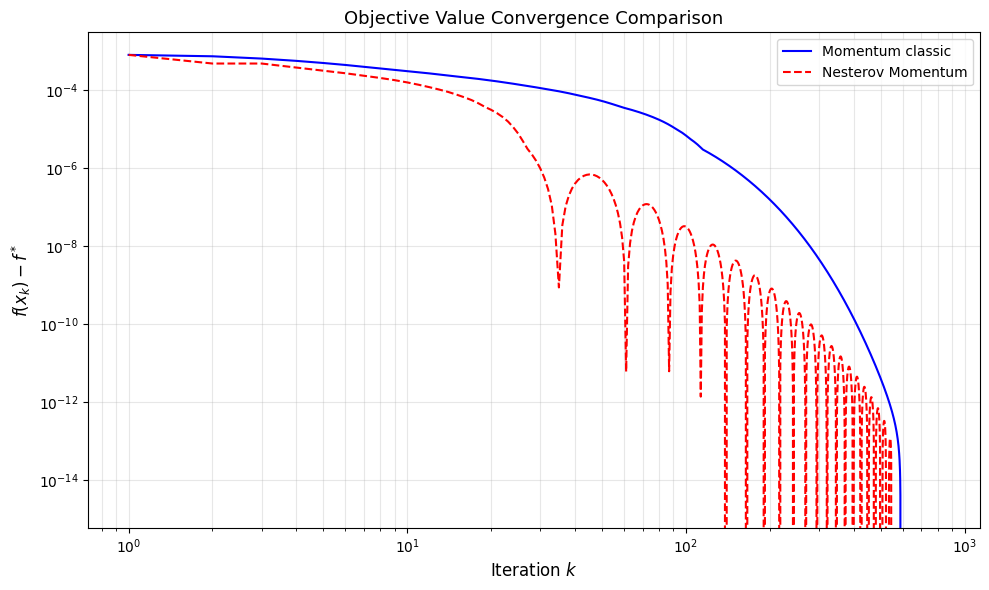

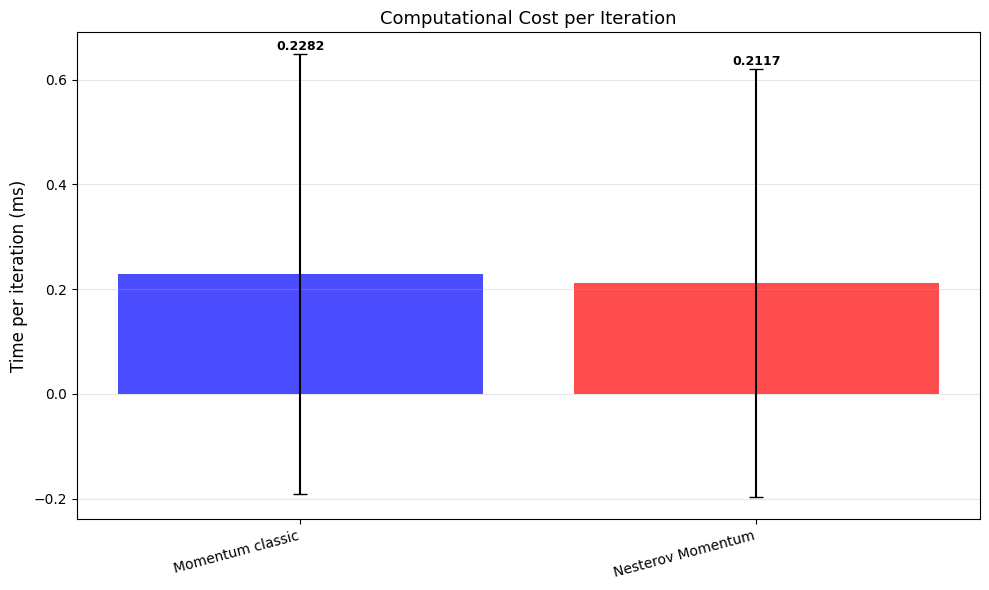


TIME PER ITERATION STATISTICS (ms)
Method                               Mean        Std     Median        Min        Max
-----------------------------------------------------------------------------------------------
Momentum classic                   0.2282     0.4199     0.0000     0.0000     1.1795
Nesterov Momentum                  0.2117     0.4087     0.0000     0.0000     1.0564

Method                          Total Time (s)   Iterations
------------------------------------------------------------
Momentum classic                        0.1850          811
Nesterov Momentum                       0.1691          799


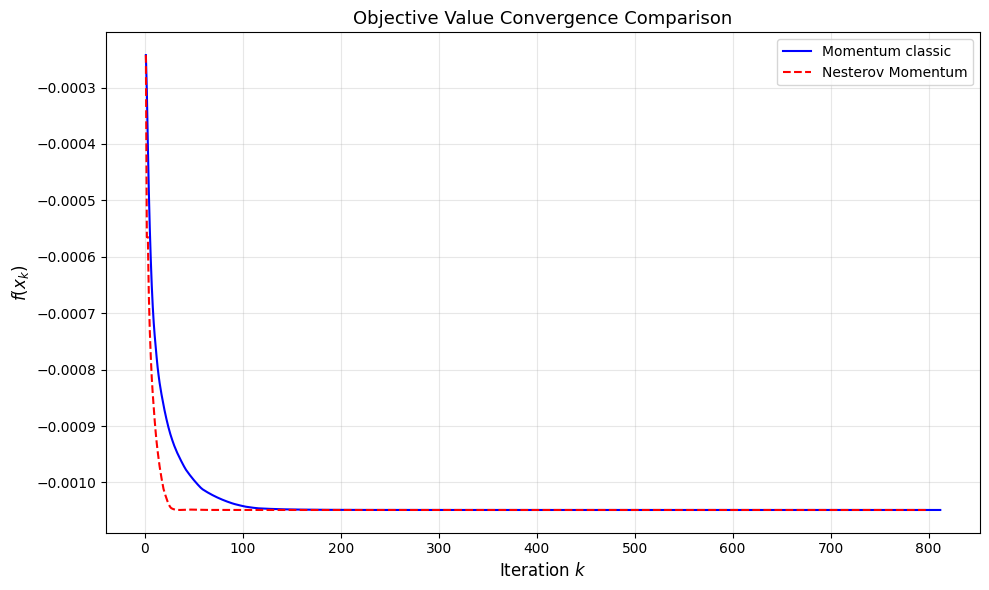

In [16]:
methods = {
    "Momentum classic": result_ProjectedGradientDescentMomentum,
    "Nesterov Momentum": result_ProjectedGradientDescentMomentum_Nesterov
}


compare_methods(methods , method_name="Comparison_Momentum_Methods" , save_dir="../figures" , metric_used='function' , f_ref = f_ref)

#### Projected Randomized Coordinate Descent

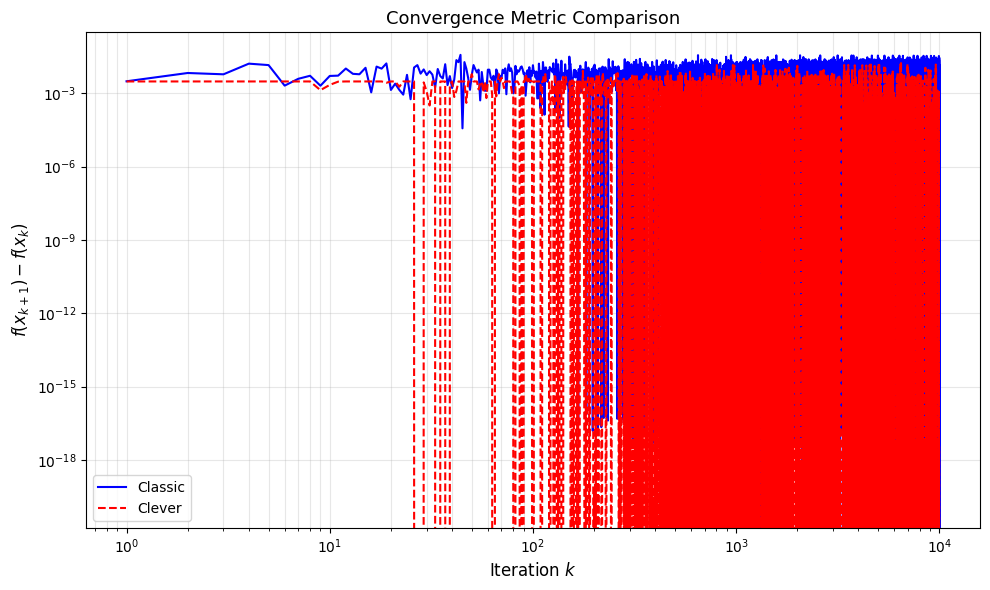

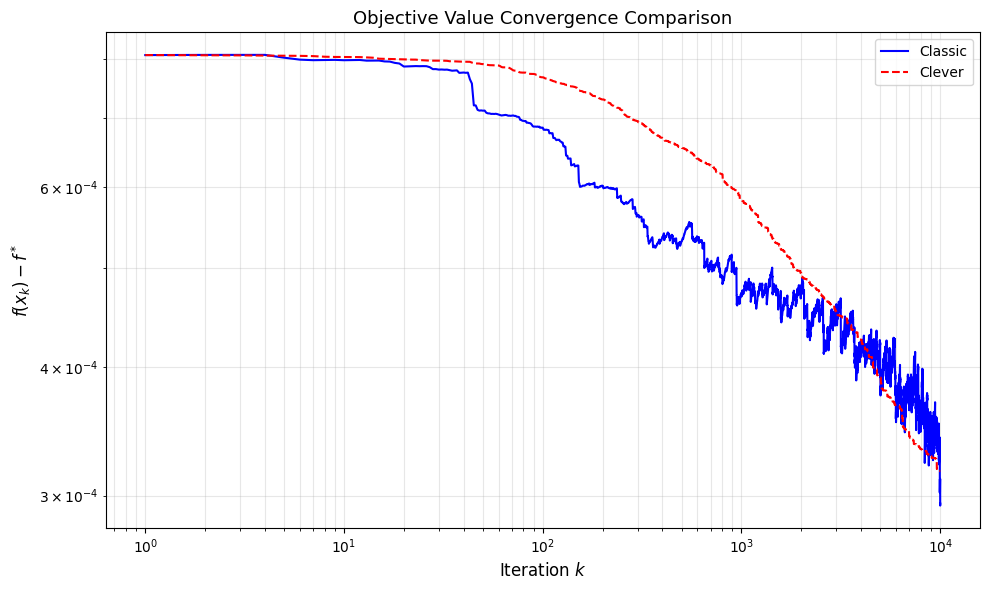

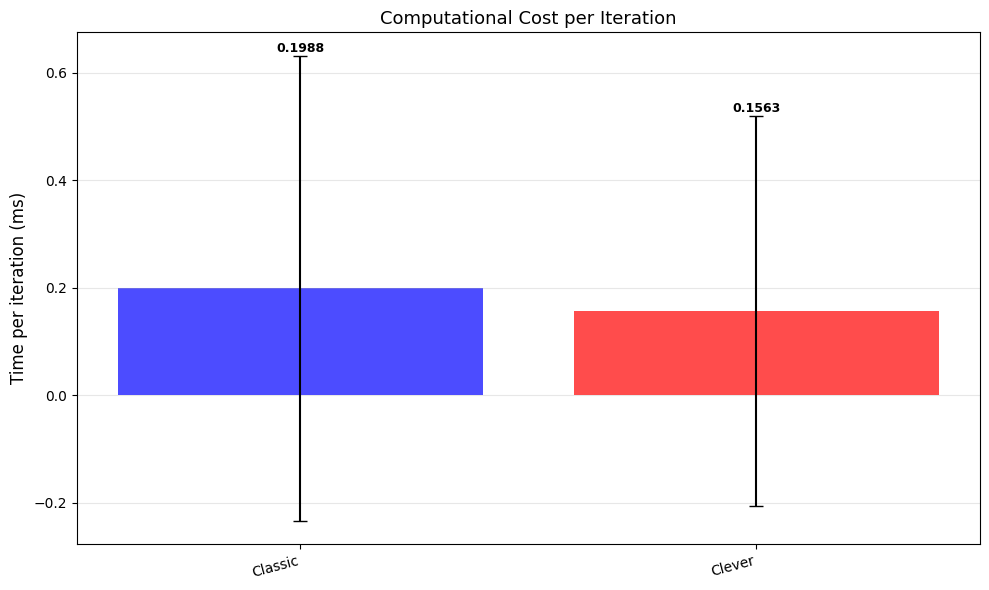


TIME PER ITERATION STATISTICS (ms)
Method                               Mean        Std     Median        Min        Max
-----------------------------------------------------------------------------------------------
Classic                            0.1988     0.4329     0.0000     0.0000     9.5348
Clever                             0.1563     0.3633     0.0000     0.0000     1.5087

Method                          Total Time (s)   Iterations
------------------------------------------------------------
Classic                                 1.9882        10000
Clever                                  1.5631        10000


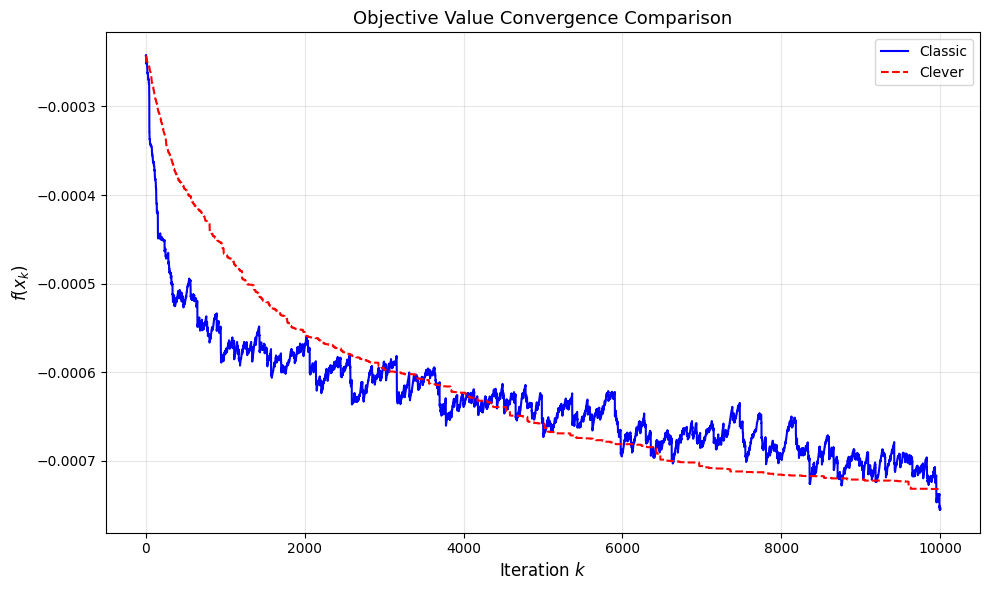

In [21]:
L = model.lipschitz_constant()

# Create optimization method instance
method1 = ProjectedRandomizedCoordinateDescent({
    'step_size': 1.0 / L,
    'max_iter': 10000,
    'tol': 1e-8,
    'iter_met': "Naive"
}, IteratePerformanceIndicator())

method2 = ProjectedRandomizedCoordinateDescent({
    'step_size': 1.0 / L,
    'max_iter': 10000,
    'tol': 1e-8,
    'iter_met': "Naive2"
}, IteratePerformanceIndicator())

method3 = ProjectedRandomizedCoordinateDescent({
    'step_size': 1.0 / L,
    'max_iter': 10000,
    'tol': 1e-8,
    'iter_met': "Cleaver"
}, IteratePerformanceIndicator())

# Optimize portfolio on training data
result1_ProjectedRandomizedCoordinateDescent = method1.optimize(model, w0)
result2_ProjectedRandomizedCoordinateDescent = method2.optimize(model, w0)
result3_ProjectedRandomizedCoordinateDescent = method3.optimize(model, w0)
methods = {"Classic": result1_ProjectedRandomizedCoordinateDescent,
           "Clever": result3_ProjectedRandomizedCoordinateDescent}
compare_methods(methods , method_name="Projected_Randomized_Coordinate_Descent_iteration_method" , save_dir="../figures" ,metric_used='function',f_ref=f_ref )


#### Analyse convergence GradientDescentRandomized

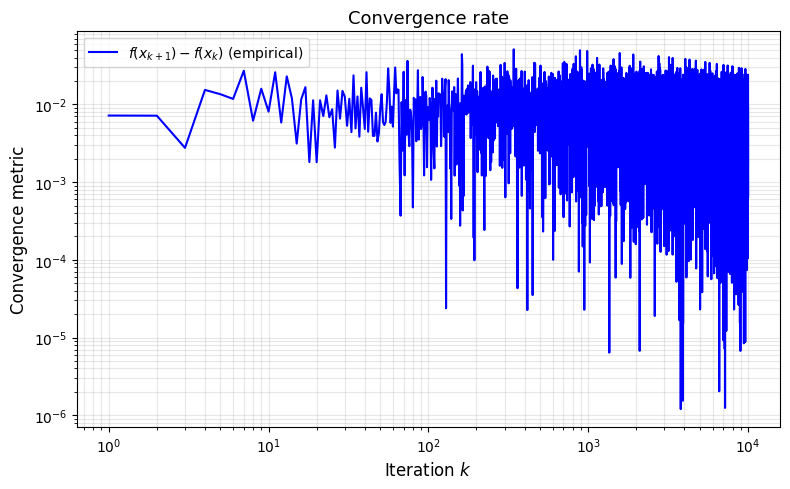

TypeError: unsupported operand type(s) for -: 'float' and 'NoneType'

<Figure size 800x500 with 0 Axes>

In [ ]:
plot_convergence(result2_ProjectedRandomizedCoordinateDescent, method_name="Projected_Randomized_Coordinate_Descent" , save_dir="../figures" , metric_used='function' , f_ref=f_ref)

#### Further analysis on Randomized coordinate descent

#### Comparaison of the methods (Basic ones)

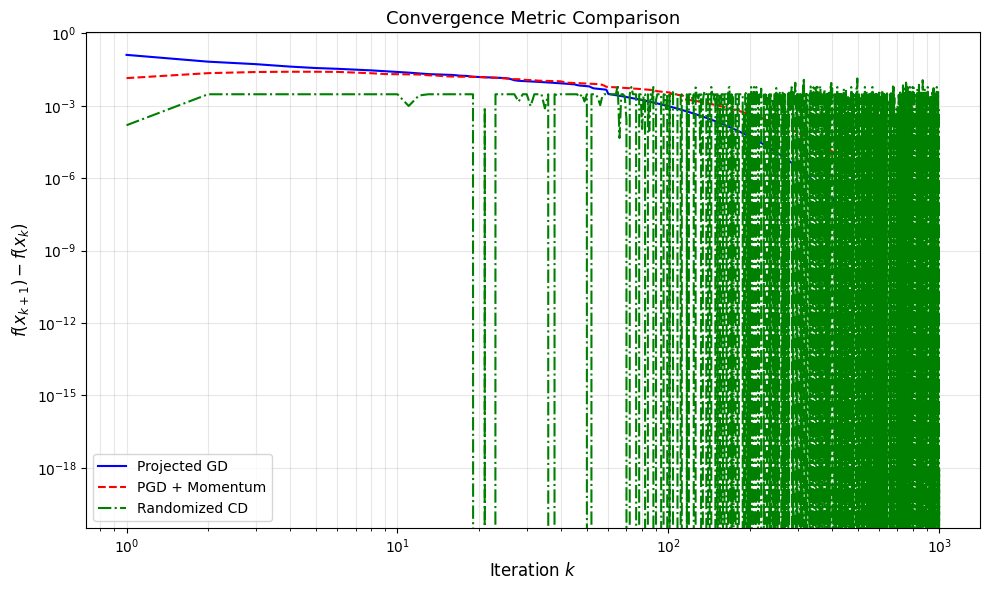

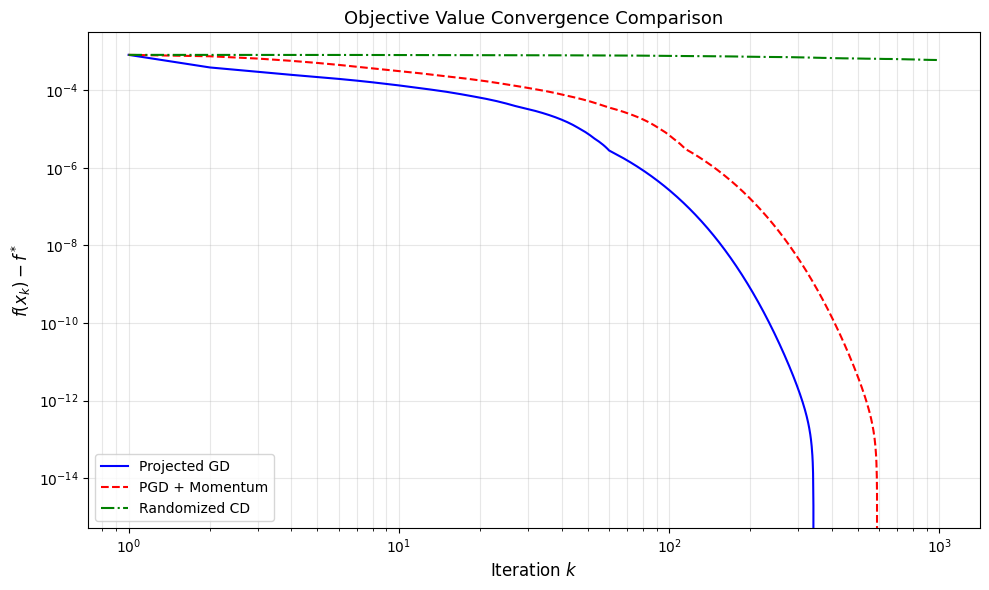

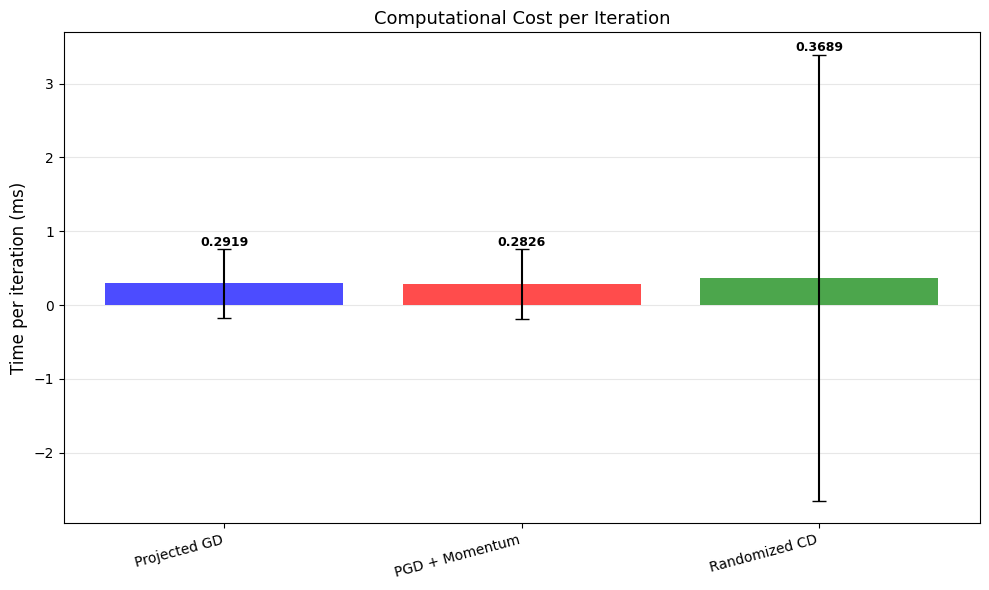


TIME PER ITERATION STATISTICS (ms)
Method                               Mean        Std     Median        Min        Max
-----------------------------------------------------------------------------------------------
Projected GD                       0.2919     0.4630     0.0000     0.0000     1.5152
PGD + Momentum                     0.2826     0.4703     0.0000     0.0000     2.0101
Randomized CD                      0.3689     3.0222     0.0000     0.0000    93.8451

Method                          Total Time (s)   Iterations
------------------------------------------------------------
Projected GD                            0.1439          493
PGD + Momentum                          0.2292          811
Randomized CD                           0.3689         1000


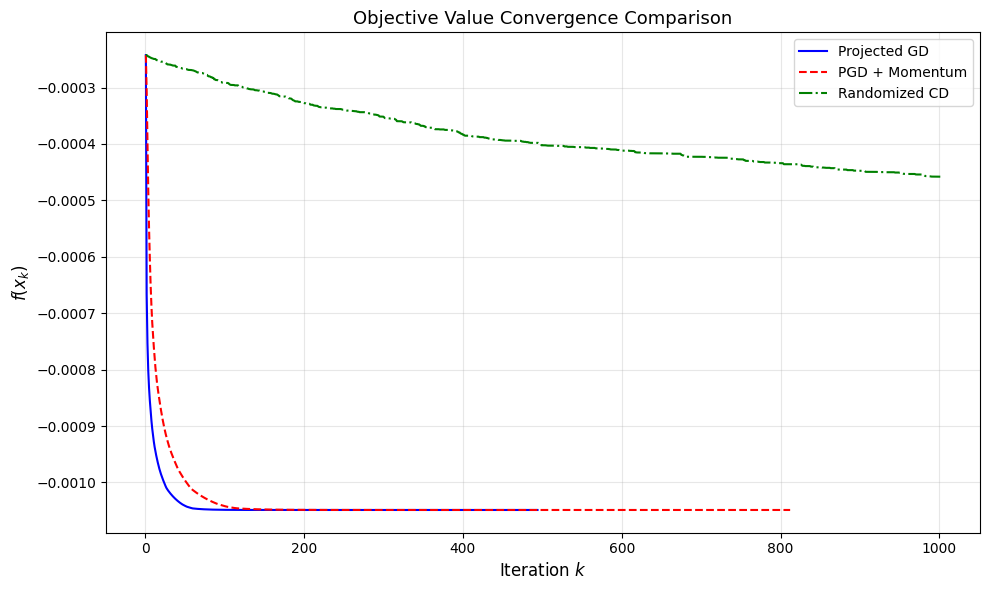

In [33]:
method3 = ProjectedRandomizedCoordinateDescent({
    'step_size': 1.0 / L,
    'max_iter': 1000,
    'tol': 1e-8,
    'iter_met': "Cleaver"
}, IteratePerformanceIndicator())
result3_ProjectedRandomizedCoordinateDescent = method3.optimize(model, w0)
compare_methods({
    'Projected GD': result_ProjectedGradientMethod,
    'PGD + Momentum': result_ProjectedGradientDescentMomentum,
    'Randomized CD': result3_ProjectedRandomizedCoordinateDescent,
}, method_name="Projected_Methods_Comparison_Worst_ones" , save_dir="../figures" , metric_used='function', f_ref=f_ref)

#### Comparaison of the methods (Best ones)

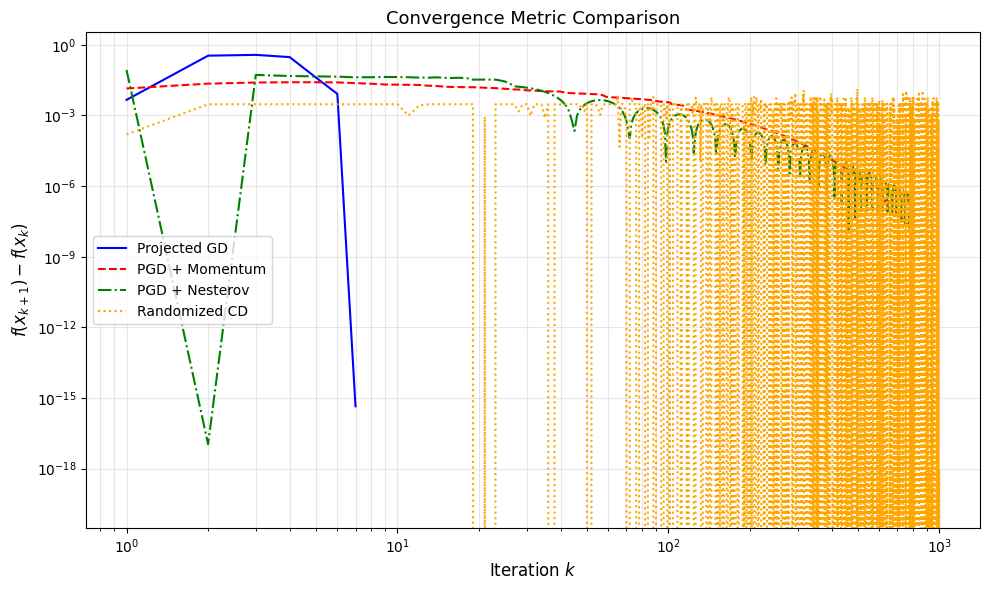

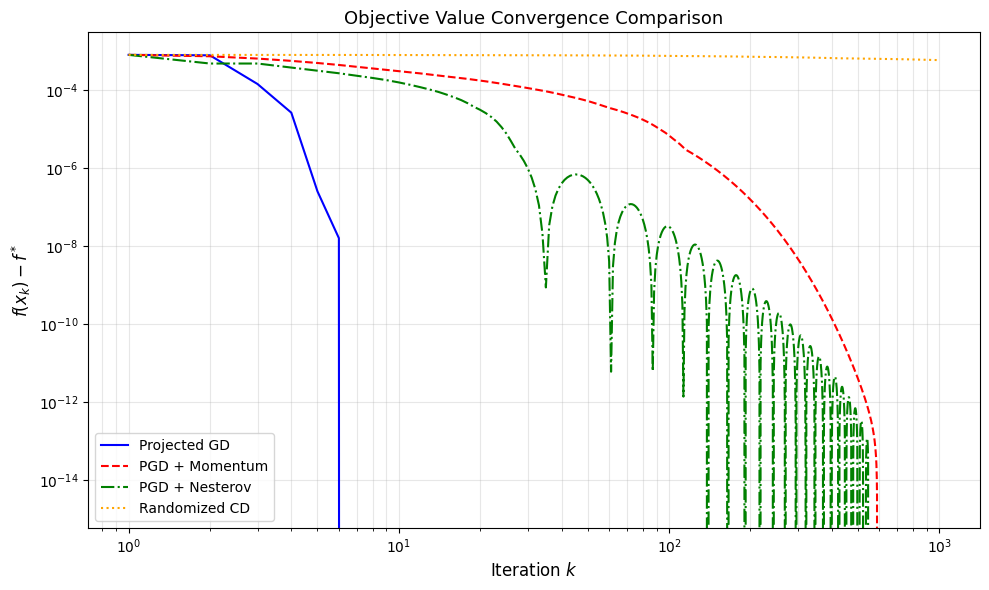

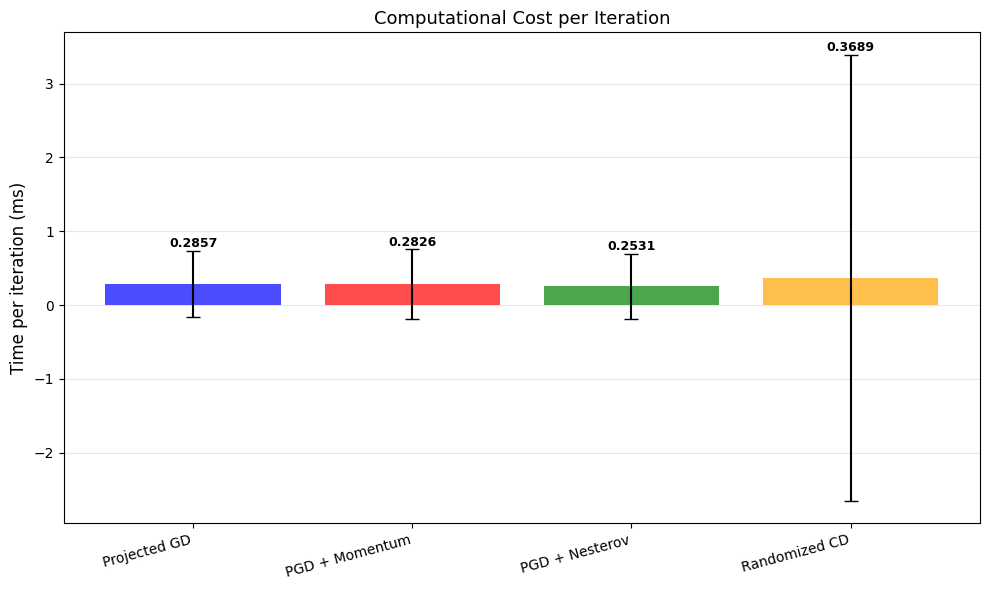


TIME PER ITERATION STATISTICS (ms)
Method                               Mean        Std     Median        Min        Max
-----------------------------------------------------------------------------------------------
Projected GD                       0.2857     0.4518     0.0000     0.0000     1.0009
PGD + Momentum                     0.2826     0.4703     0.0000     0.0000     2.0101
PGD + Nesterov                     0.2531     0.4449     0.0000     0.0000     1.5047
Randomized CD                      0.3689     3.0222     0.0000     0.0000    93.8451

Method                          Total Time (s)   Iterations
------------------------------------------------------------
Projected GD                            0.0020            7
PGD + Momentum                          0.2292          811
PGD + Nesterov                          0.2022          799
Randomized CD                           0.3689         1000


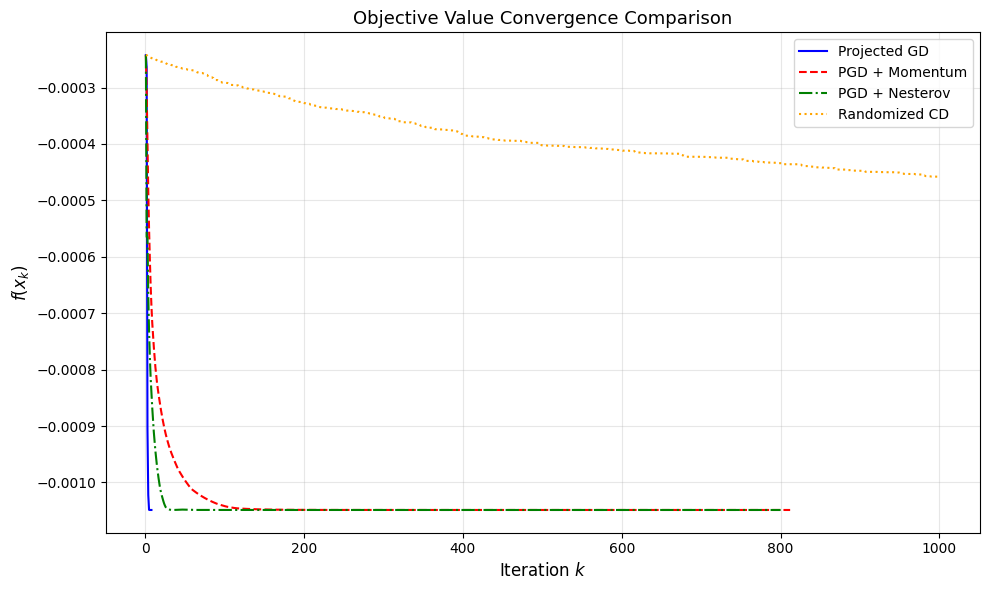

In [34]:
compare_methods({
    'Projected GD': method4_result_PG,
    'PGD + Momentum': result_ProjectedGradientDescentMomentum,
    'PGD + Nesterov': result_ProjectedGradientDescentMomentum_Nesterov,
    'Randomized CD': result3_ProjectedRandomizedCoordinateDescent,

}, method_name="Projected_Methods_Comparison_Best_ones" , save_dir="../figures" , metric_used='function' , f_ref=f_ref  )

#### Analyse parameters c and lambda

In [53]:
import cvxpy as cp

def solve_markowitz_cvxpy(mu, sigma, lam):
    """Solve smooth Markowitz problem and return f*, risk*, return*, w*."""
    n = len(mu)
    w = cp.Variable(n)

    objective = cp.Minimize(0.5 * cp.quad_form(w, sigma) - lam * mu @ w)
    constraints = [cp.sum(w) == 1, w >= 0]

    problem = cp.Problem(objective, constraints)
    problem.solve(solver=cp.ECOS)

    w_star = w.value
    risk_star = 0.5 * w_star.T @ sigma @ w_star
    return_star = mu.T @ w_star

    return problem.value, risk_star, return_star, w_star

def compute_efficient_frontier(data, lambda_values):
    """
    Compute the efficient frontier (smooth case) by varying lambda.

    Returns:
        risks: array of optimal risks
        returns: array of optimal returns
    """
    mu = data['mu']
    sigma = data['sigma']

    risks = []
    returns = []

    for lam in lambda_values:
        _, risk_star, return_star, _ = solve_markowitz_cvxpy(mu, sigma, lam)
        risks.append(risk_star)
        returns.append(return_star)

    return np.array(risks), np.array(returns)

def plot_efficient_frontier(data, lambda_values, save_dir="../figures"):
    """
    Plot the smooth efficient frontier (risk vs return).
    """
    risks, returns = compute_efficient_frontier(data, lambda_values)
    

    plt.figure(figsize=(10, 7))
    plt.plot(risks, returns, 'o-', linewidth=2, markersize=8)
    
    # Add lambda labels to each point
    for i, lam in enumerate(lambda_values):
        plt.annotate(f'λ={lam}', (risks[i], returns[i]), 
                     textcoords="offset points", xytext=(8, 5), fontsize=9,
                     bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))
    
    plt.xlabel(r'Risk $\frac{1}{2} w^T \Sigma w$', fontsize=12)
    plt.ylabel(r'Expected Return $\mu^T w$', fontsize=12)
    plt.title('Efficient Frontier (Smooth Markowitz)', fontsize=13)
    plt.grid(True, alpha=0.3)

    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)
        plt.savefig(os.path.join(save_dir, 'efficient_frontier_smooth.png'),
                    dpi=150, bbox_inches='tight')

    plt.show()


def run_optimization_with_tracking(data, lam, max_iter=1000, tol=1e-8):
    """
    Run optimization and track risk, return, and objective at each iteration.
    
    Returns:
        dict with 'risks', 'returns', 'obj_values', 'iterations'
    """
    mu = data['mu']
    sigma = data['sigma']
    n = len(mu)
    
    # Initialize
    w = get_initial_portfolio(n)
    L = np.linalg.norm(sigma, 2)
    
    # Storage
    risks = []
    returns = []
    obj_values = []
    
    # Barzilai-Borwein state
    w_prev = None
    grad_prev = None
    alpha = 1.0 / L
    
    for k in range(max_iter):
        # Compute current risk and return
        risk = 0.5 * w.T @ sigma @ w
        ret = mu.T @ w
        obj = risk - lam * ret
        
        risks.append(risk)
        returns.append(ret)
        obj_values.append(obj)
        
        # Gradient
        grad = sigma @ w - lam * mu
        
        # Barzilai-Borwein step size
        if w_prev is not None and grad_prev is not None:
            s = w - w_prev
            y = grad - grad_prev
            s_dot_y = np.dot(s, y)
            s_dot_s = np.dot(s, s)
            if abs(s_dot_y) > 1e-14:
                alpha = s_dot_s / s_dot_y
                alpha = np.clip(alpha, 1e-10, 1e10)
        
        w_prev = w.copy()
        grad_prev = grad.copy()
        
        # Update
        w_new = simplex_projection(w - alpha * grad)
        
        # Check convergence
        if np.linalg.norm(w_new - w) < tol:
            w = w_new
            # Record final values
            risk = 0.5 * w.T @ sigma @ w
            ret = mu.T @ w
            obj = risk - lam * ret
            risks.append(risk)
            returns.append(ret)
            obj_values.append(obj)
            break
        
        w = w_new
    
    return {
        'risks': np.array(risks),
        'returns': np.array(returns),
        'obj_values': np.array(obj_values),
        'iterations': len(risks),
        'final_w': w
    }

def analyse_lambda_parameter(data, lambda_values, max_iter=1000, tol=1e-8, save_dir="../figures"):
    """
    Analyse the effect of lambda on risk, return, and convergence.
    
    Creates 3 separate plots:
    1. Return vs iterations for each lambda
    2. Risk vs iterations for each lambda
    3. f(x_k) - f* vs iterations (where f* from CVXPY)
    """
    mu = data['mu']
    sigma = data['sigma']
    
    colors = ['b', 'r', 'g', 'orange', 'purple', 'brown', 'pink', 'cyan']
    
    # Store results
    all_results = {}
    f_stars = {}
    
    for lam in lambda_values:
        # Get optimal f* from CVXPY
        f_star,_,_, w_star = solve_markowitz_cvxpy(mu, sigma, lam)
        f_stars[lam] = f_star
        
        # Run optimization with tracking
        result = run_optimization_with_tracking(data, lam, max_iter, tol)
        all_results[lam] = result
        
        print(f"λ = {lam}: {result['iterations']} iters, f* = {f_star:.6f}, final f = {result['obj_values'][-1]:.6f}")
    
    # Create save directory
    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)
    
    # --- Plot 1: Return vs iterations ---
    plt.figure(figsize=(10, 6))
    for i, lam in enumerate(lambda_values):
        result = all_results[lam]
        iterations = np.arange(1, len(result['returns']) + 1)
        plt.plot(iterations, result['returns'], color=colors[i % len(colors)], 
                 linewidth=1.5, label=f'λ = {lam}')
    
    plt.xlabel('Iteration $k$', fontsize=12)
    plt.ylabel(r'Expected Return $\mu^T w_k$', fontsize=12)
    plt.title('Expected Return vs Iterations', fontsize=13)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    if save_dir is not None:
        plt.savefig(os.path.join(save_dir, 'lambda_return_vs_iterations.png'), dpi=150, bbox_inches='tight')
    plt.show()
    
    # --- Plot 2: Risk vs iterations ---
    plt.figure(figsize=(10, 6))
    for i, lam in enumerate(lambda_values):
        result = all_results[lam]
        iterations = np.arange(1, len(result['risks']) + 1)
        plt.plot(iterations, result['risks'], color=colors[i % len(colors)], 
                 linewidth=1.5, label=f'λ = {lam}')
    
    plt.xlabel('Iteration $k$', fontsize=12)
    plt.ylabel(r'Risk $\frac{1}{2} w_k^T \Sigma w_k$', fontsize=12)
    plt.title('Portfolio Risk vs Iterations', fontsize=13)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    if save_dir is not None:
        plt.savefig(os.path.join(save_dir, 'lambda_risk_vs_iterations.png'), dpi=150, bbox_inches='tight')
    plt.show()
    
    # --- Plot 3: f(x_k) - f* vs iterations ---
    plt.figure(figsize=(10, 6))
    for i, lam in enumerate(lambda_values):
        result = all_results[lam]
        iterations = np.arange(1, len(result['obj_values']) + 1)
        gap = result['obj_values'] - f_stars[lam]
        # Handle negative/zero values for log scale
        gap = np.maximum(gap, 1e-16)
        plt.semilogy(iterations, gap, color=colors[i % len(colors)], 
                     linewidth=1.5, label=f'λ = {lam}')
    
    plt.xlabel('Iteration $k$', fontsize=12)
    plt.ylabel(r'$f(w_k) - f^*$', fontsize=12)
    plt.title('Convergence to Optimal Value (from CVXPY)', fontsize=13)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3, which='both')
    plt.tight_layout()
    if save_dir is not None:
        plt.savefig(os.path.join(save_dir, 'lambda_convergence_gap.png'), dpi=150, bbox_inches='tight')
    plt.show()
    
    # Print summary table
    print("\n" + "="*80)
    print("LAMBDA PARAMETER ANALYSIS SUMMARY")
    print("="*80)
    print(f"{'Lambda':<10} {'f*':>12} {'Final f':>12} {'Gap':>12} {'Final Risk':>12} {'Final Return':>12}")
    print("-"*80)
    for lam in lambda_values:
        result = all_results[lam]
        gap = result['obj_values'][-1] - f_stars[lam]
        print(f"{lam:<10} {f_stars[lam]:>12.6f} {result['obj_values'][-1]:>12.6f} {gap:>12.2e} {result['risks'][-1]:>12.6f} {result['returns'][-1]:>12.6f}")
    print("="*80)
    
    return all_results, f_stars

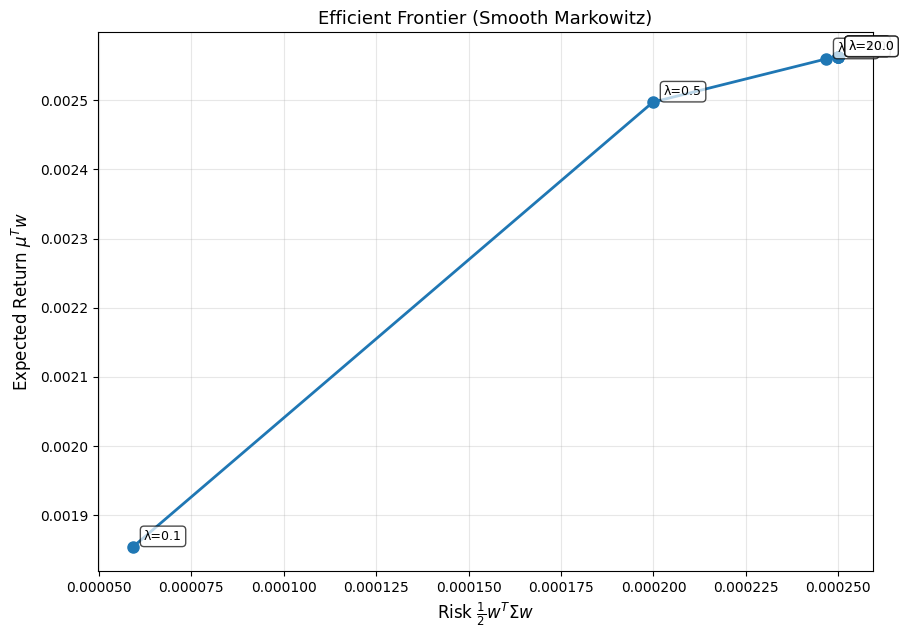

λ = 0.1: 69 iters, f* = -0.000126, final f = -0.000126
λ = 0.5: 8 iters, f* = -0.001049, final f = -0.001049
λ = 1.0: 7 iters, f* = -0.002313, final f = -0.002313
λ = 2.0: 5 iters, f* = -0.004876, final f = -0.004876
λ = 5.0: 4 iters, f* = -0.012564, final f = -0.012564
λ = 10.0: 4 iters, f* = -0.025377, final f = -0.025377
λ = 20.0: 4 iters, f* = -0.051003, final f = -0.051003


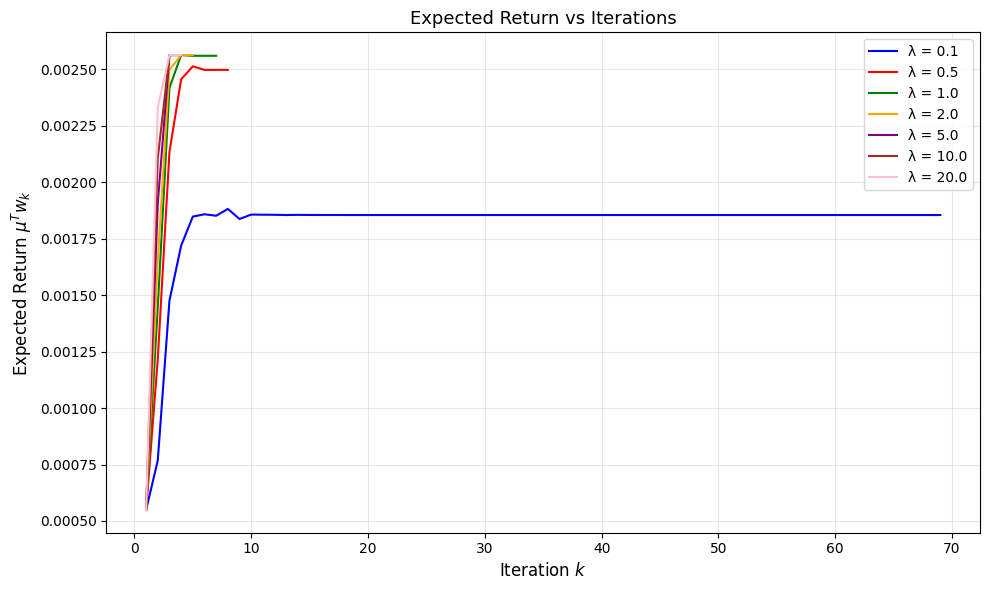

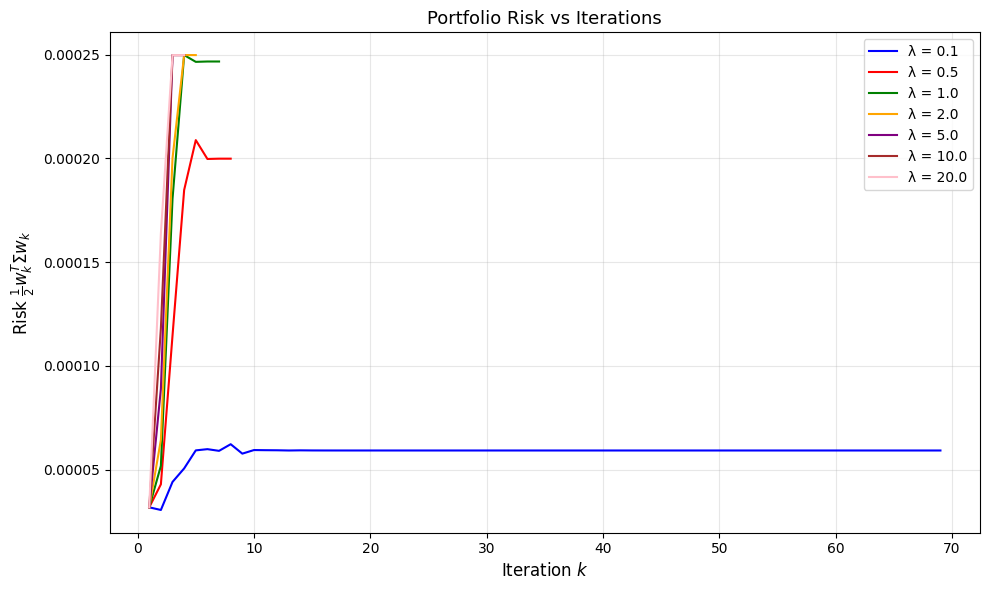

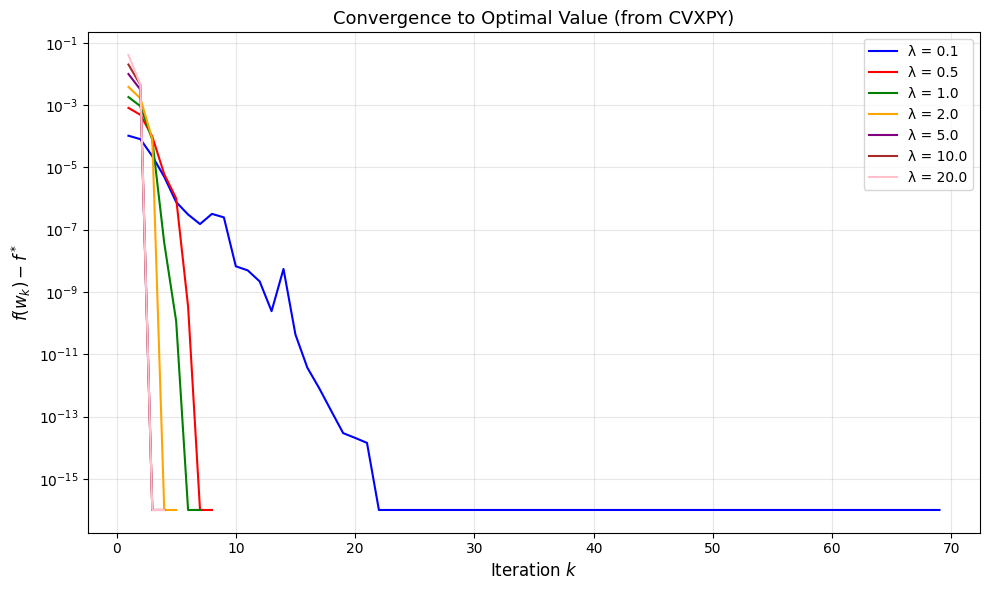


LAMBDA PARAMETER ANALYSIS SUMMARY
Lambda               f*      Final f          Gap   Final Risk Final Return
--------------------------------------------------------------------------------
0.1           -0.000126    -0.000126    -9.28e-14     0.000059     0.001855
0.5           -0.001049    -0.001049    -1.90e-13     0.000200     0.002497
1.0           -0.002313    -0.002313    -5.71e-14     0.000247     0.002560
2.0           -0.004876    -0.004876    -1.90e-13     0.000250     0.002563
5.0           -0.012564    -0.012564    -1.70e-13     0.000250     0.002563
10.0          -0.025377    -0.025377    -3.07e-13     0.000250     0.002563
20.0          -0.051003    -0.051003    -4.82e-13     0.000250     0.002563


In [54]:
# Analyse lambda parameter effect
lambda_values = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0 , 20.0]

plot_efficient_frontier(data, lambda_values)

results_lambda, f_stars = analyse_lambda_parameter(data, lambda_values)